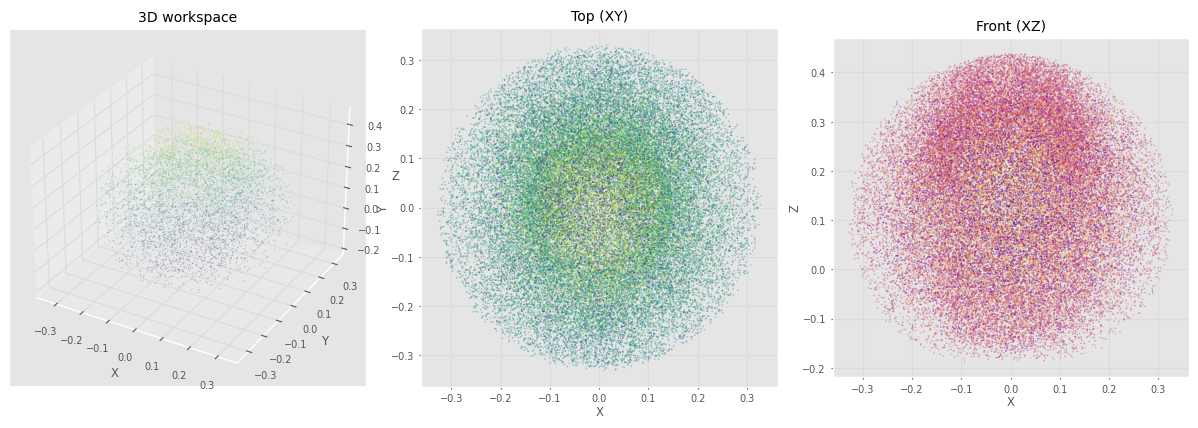

Reach range
X: [-0.328, 0.330]
Y: [-0.331, 0.331]
Z: [-0.187, 0.438]


In [1]:
import roboticstoolbox as rtb
import numpy as np
import matplotlib.pyplot as plt
import os

robot = rtb.ERobot.URDF(os.path.abspath("robot.urdf"))

# Sample N random configs within joint limits
N = 50_000
qlim = robot.qlim          # shape (2, 6)  — row 0 = min, row 1 = max

q_samples = np.random.uniform(
    low=qlim[0], high=qlim[1], size=(N, robot.n)
)

# FK for all samples at once
points = np.array([robot.fkine(q).t for q in q_samples])  # (N, 3)

fig = plt.figure(figsize=(12, 5))

# 3D
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(points[::10,0], points[::10,1], points[::10,2],
            s=0.3, alpha=0.2, c=points[::10,2], cmap='viridis')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_title('3D workspace')

# XY top-down view
ax2 = fig.add_subplot(132)
ax2.scatter(points[:,0], points[:,1], s=0.5, alpha=0.3, c=points[:,2], cmap='viridis')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_title('Top (XY)')
ax2.set_aspect('equal')

# XZ front view
ax3 = fig.add_subplot(133)
ax3.scatter(points[:,0], points[:,2], s=0.5, alpha=0.3, c=points[:,1], cmap='plasma')
ax3.set_xlabel('X'); ax3.set_ylabel('Z'); ax3.set_title('Front (XZ)')
ax3.set_aspect('equal')

plt.tight_layout()
plt.savefig('workspace.png', dpi=600)
plt.show()
print(f"Reach range")
print(f"X: [{points[:,0].min():.3f}, {points[:,0].max():.3f}]")
print(f"Y: [{points[:,1].min():.3f}, {points[:,1].max():.3f}]")
print(f"Z: [{points[:,2].min():.3f}, {points[:,2].max():.3f}]")